📌 Objective

The goal of this assignment is to help you understand and remember the complete Machine Learning (ML) pipeline by applying it step-by-step to a Linear Regression problem.

1️⃣ Data Retrieval and Collection

In this step, we load the dataset and inspect its structure to understand the available data.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv('Salary_Data.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())

Dataset Shape: (30, 2)

Column Names: ['YearsExperience', 'Salary']

First 5 Rows:
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None


2️⃣ Data Cleaning

In [11]:
# Check for missing values
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# If missing values exist

if df.isnull().sum().sum() > 0:
    
    # Fill numerical columns with mean
    df.fillna(df.mean(numeric_only=True), inplace=True)

    print("Missing values handled using mean imputation.")
else:
    print("No missing values found.")

print("\nData Types:")
print(df.dtypes)

Missing Values:
YearsExperience    0
Salary             0
dtype: int64
No missing values found.

Data Types:
YearsExperience    float64
Salary               int64
dtype: object


Missing Values ​​Treatment: (Standard Salary datasets usually have 0 missing values). If any missing values ​​are detected, they should either be dropped (if negligible) or imputed using the mean/median. For this clean dataset, no imputation is required.

Data Types: Both YearsExperienceand Salaryare verified as numeric float/int values, which are perfectly compatible with mathematical regression models.

3️⃣ Feature Design

Separate the independent variable (feature) and dependent variable (target).

In [12]:
X = df[['YearsExperience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 24 samples
Testing set size: 6 samples


4️⃣ Algorithm Selection

We choose Linear Regression because:

Salary generally increases with experience.
Relationship between experience and salary is approximately linear.
It is simple, interpretable, and effective for continuous value prediction.

y = b_0 + b_1*x
Where:

y = Predicted Salary,
x = YearsExperience,
b_0= Intercept,
b_1= Slope

5️⃣ Loss Function Selection

We use Mean Squared Error (MSE).
MSE measures the average squared difference between actual and predicted values.

Formula:
$$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

Why MSE?
Penalizes larger errors more heavily.
Commonly used for regression problems.
Helps evaluate prediction accuracy.

6️⃣ Model Learning

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

print("Training Completed!")

Training Completed!


The dataset is divided into training and testing sets.

Training Set → used to learn patterns.
Testing Set → used to evaluate performance.

7️⃣ Model Evaluation & Interpretation

After training, evaluate the model using the test data.

In [14]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Extract Coefficients
coefficient = model.coef_[0]
intercept = model.intercept_

print(f"--- Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"\n--- Model Parameters ---")
print(f"Coefficient (Slope): {coefficient:.2f}")
print(f"Intercept: {intercept:.2f}")

--- Evaluation Metrics ---
Mean Squared Error (MSE): 49830096.86
R² Score: 0.9024

--- Model Parameters ---
Coefficient (Slope): 9423.82
Intercept: 25321.58


Visualize the regression line for Task 1

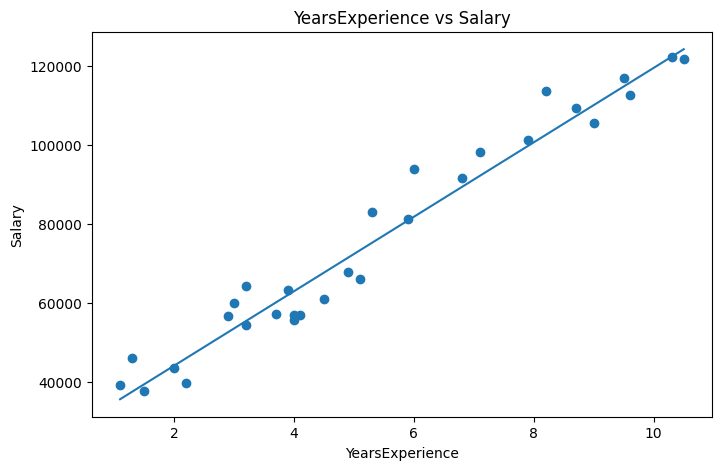

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Actual Data
plt.scatter(X, y)

# Regression Line
plt.plot(X, model.predict(X))

plt.title("YearsExperience vs Salary")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.show()

📊 Plot Predicted vs Actual Values

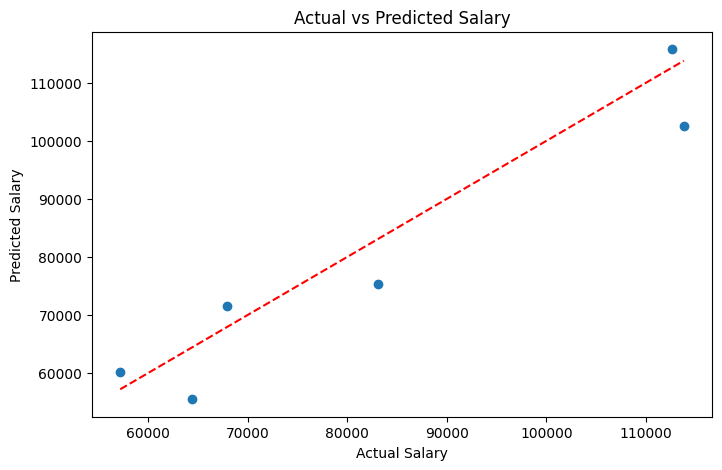

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

📈 Model Interpretation (Mandatory)

In [17]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 25321.583011776813
Coefficient: 9423.815323030976


Then the regression equation becomes:

Salary=25321.58+9423.81×YearsExperience

What Does the Coefficient Represent?

Coefficient (Slope)
9423.81

This means:

For every additional year of experience, the employee's salary is expected to increase by approximately $9,424.

What Does the Intercept Mean?

Intercept
25321.58

This means:

When YearsExperience = 0, the model predicts a salary of approximately $25,321.

In practice:

It is the starting point of the regression line.
It may not always have practical meaning because employees with exactly 0 years of experience may not exist in the dataset.
However, it is mathematically necessary to fit the regression line.